## Homework 4: Evaluation

This is the personal implementation of the homework 4 of [ML Zoomcamp 2026](https://github.com/DataTalksClub/machine-learning-zoomcamp).

In [1]:
# get the data
!wget https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv

--2026-09-27 14:44:24--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 278746 (272K) [text/plain]
Saving to: ‘course_lead_scoring_2026.csv’

course_lead_scoring 100%[===================>] 272.21K  --.-KB/s    in 0.1s    

2026-09-27 14:44:25 (2.01 MB/s) - ‘course_lead_scoring_2026.csv’ saved [278746/278746]



In [2]:
# load necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("course_lead_scoring_2026.csv")
df.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


In [3]:
# check missing values
df.isnull().sum()

lead_source                 148
industry                    240
employment_status           194
location                    208
annual_income               369
number_of_courses_viewed      0
interaction_count             0
lead_score                   35
converted                     0
dtype: int64

In [4]:
# define categorical and numerical features
categorical = [
    'lead_source',
    'industry',
    'employment_status',
    'location'
]

numerical = [
    'annual_income',
    'number_of_courses_viewed',
    'interaction_count',
    'lead_score'
]

# fill missing categorical values with 'NA'
df[categorical] = df[categorical].fillna('NA')

# fill missing numerical values with 0.0
df[numerical] = df[numerical].fillna(0.0)

# check again
df.isnull().sum()

lead_source                 0
industry                    0
employment_status           0
location                    0
annual_income               0
number_of_courses_viewed    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

In [5]:
from sklearn.model_selection import train_test_split

# split the data
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(
    df_full_train, test_size=0.25, random_state=1
)

# reset index for each
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

# separate target variable
y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values

# delete target variable data from features
del df_train['converted']
del df_val['converted']
del df_test['converted']

# get the size of each set
print("Total size:", len(df))
print(f"Train, Val, Test: ({len(df_train)}, {len(df_val)}, {len(df_test)})")
print(f"y_train, y_val, y_test: ({len(y_train)}, {len(y_val)}, {len(y_test)})")

Total size: 5000
Train, Val, Test: (3000, 1000, 1000)
y_train, y_val, y_test: (3000, 1000, 1000)


#### Q1. Which numerical variable (among the following 4) has the highest AUC?

In [6]:
from sklearn.metrics import roc_auc_score

# set each numeric column as score
y_income = df_train['annual_income']
y_viewed = df_train['number_of_courses_viewed']
y_interaction = df_train['interaction_count']
y_lead = df_train['lead_score']

# roc auc score for each
print("Annual Income:", roc_auc_score(y_train, y_income))
print("Number of Courses Viewed:", roc_auc_score(y_train, y_viewed))
print("Interaction Count:", roc_auc_score(y_train, y_interaction))
print("Lead Score:", roc_auc_score(y_train, y_lead))

print("Highest score: Lead Score =", roc_auc_score(y_train, y_lead))

Annual Income: 0.6081977776250831
Number of Courses Viewed: 0.7229894623989618
Interaction Count: 0.7649203047563227
Lead Score: 0.7882254810906102
Highest score: Lead Score = 0.7882254810906102


#### Q2. What's the AUC of this model on the validation dataset? (round to 3 digits)

In [7]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

def train(df, y, categorical=categorical, numerical=numerical, C=1.0):
    # create a dict vectorizer (do not use sparse matrices) for one-hot encoding
    dv = DictVectorizer(sparse=False)

    # fit data to vectorizer and transform into one-hot-encoded (dict vectorizer does this only for categorical data)
    dicts = df[categorical + numerical].to_dict(orient='records')
    X = dv.fit_transform(dicts)

    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)

    # fit trains the model from scratch
    model.fit(X, y)

    return dv, model


def predict(df, dv, model):
    dicts = df[categorical + numerical].to_dict(orient='records')
    X = dv.transform(dicts)
    # probability of converted = 1
    y = model.predict_proba(X)[:, 1]
    return y

In [8]:
# train the model
dv, model = train(df_train, y_train)
# predict the outcomes
y_pred = predict(df_val, dv, model)

# roc auc on validation
print(f"ROC AUC Score: {roc_auc_score(y_val, y_pred):.3f}")

ROC AUC Score: 0.732


#### Q3. At which threshold precision and recall curves intersect? 

In [13]:
def get_scores(y_pred, y_val):
    # find true positive, true negative, false positive and false negative
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)
    scores = []
    thresholds = np.arange(0.0, 1.01, 0.01)

    for t in thresholds:
        predict_positive = (y_pred >= t)
        predict_negative = (y_pred < t)

        tp = (predict_positive & actual_positive).sum()
        tn = (predict_negative & actual_negative).sum()
        fp = (predict_positive & actual_negative).sum()
        fn = (predict_negative & actual_positive).sum()

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0

        scores.append((t, tp, tn, fp, fn, precision, recall))

    return scores

scores = get_scores(y_pred, y_val)
df_scores = pd.DataFrame(
    scores,
    columns = ['threshold', 'tp', 'tn', 'fp', 'fn', 'precision', 'recall']
)

Min diff threshold: 0.63


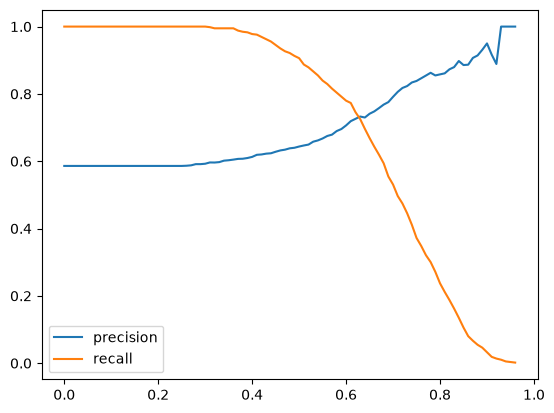

In [42]:
# remove where both are 0
df_scores = df_scores[~((df_scores['precision'] == 0) & (df_scores['recall'] == 0))]

# set abs difference as a new column
df_scores['diff'] = np.abs(df_scores['precision'] - df_scores['recall'])

# plot the tresholds vs metrics
plt.plot(df_scores.threshold, df_scores['precision'], label='precision')
plt.plot(df_scores.threshold, df_scores['recall'], label='recall')
plt.legend()

# smallest difference treshold
print(f"Min diff threshold: {df_scores.loc[df_scores['diff'].idxmin()].threshold:.2f}")

#### Q4. At which threshold F1 is maximal?

In [43]:
df_scores['f1'] = (
    2 * df_scores['precision'] * df_scores['recall']
    / (df_scores['precision'] + df_scores['recall'])
)

# maximal f1 threshold
print(f"Max F1 threshold: {df_scores.loc[df_scores['f1'].idxmax()].threshold:.2f}")

Max F1 threshold: 0.41


#### Q5. How large is standard deviation of the scores across different folds?

In [45]:
from sklearn.model_selection import KFold
from tqdm.auto import tqdm

n_splits = 5

kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

kf_scores = []

for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]
    
    y_train = df_train.converted.values
    y_val = df_val.converted.values
    
    dv, model = train(df_train, y_train)
    y_pred = predict(df_val, dv, model)
    
    auc = roc_auc_score(y_val, y_pred)
    kf_scores.append(auc)

print(f"Std Across Folds: {np.std(kf_scores):.3f}")

Std Across Folds: 0.007


#### Q6. Which C leads to the best mean ROC AUC?

In [46]:
n_splits = 5

for C in tqdm([0.000001, 0.001, 1]):
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

    C_scores = []

    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        y_train = df_train.converted.values
        y_val = df_val.converted.values

        dv, model = train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)
        C_scores.append(auc)

    print(f"C: {C} | Mean: {np.mean(C_scores):.3f} | Std: {np.std(C_scores):.3f}")

  0%|          | 0/3 [00:00<?, ?it/s]

C: 1e-06 | Mean: 0.617 | Std: 0.019
C: 0.001 | Mean: 0.749 | Std: 0.010
C: 1 | Mean: 0.732 | Std: 0.007
